# General model ($S_0, S_1, T_1, B$)
This model comprises the ground state $S_0$, the excited singlet state $S_1$, the excited triplet state $T_1$ and the bleached state $B$.

In [4]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import matplotlib.pyplot as plt
import src.fluorophore_systems as fs
import src.custom_plot as cp
import src.large_scale as ls
import src.figures as fi
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

[autoreload of src.animations failed: Traceback (most recent call last):
  File "C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\IPython\extensions\autoreload.py", line 257, in check
    superreload(m, reload, self.old_objects)
  File "C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\IPython\extensions\autoreload.py", line 455, in superreload
    module = reload(module)
  File "C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\importlib\__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "C:\Users\vie43sq\OneDrive - Universität Würzburg\GitHub\Photoswitching\src\animations.py",

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define the state transition rates

In [5]:
rate_dict = dict(k_S0_S1=[7e6, "excitation"],  
                 k_S1_S0=[1e9, "fluorescent emission"], 
                 k_S1_T1=[1e6, "intersystem crossing"],   
                 k_T1_S0=[5e5, "vibrational relaxation"],  
                 k_S1_B=[1e8, "bleaching"])

### Initialize system

In [6]:
system = fs.GeneralModel(number=2, distances=1, rates=rate_dict)

### Simulate the Markov process

In [7]:
system.simulate(n_steps=100000, seed=99, base="py")

### Receive emission events

In [8]:
system.emitters(unit="s", resample="0.05ms", photon_collection=1)

### Unique states and their occupation times
Example: S0_S1 and S1_S0 are united

In [9]:
system.process()

### Fluoresecence correlation (Autocorrelation)

In [10]:
system.fcs()

C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\multipletau\core.py:215: RuntimeWarning: divide by zero encountered in double_scalars
  if np.abs(traceavg) / np.median(np.abs(trace)) < ZERO_CUTOFF:


ValueError: `len(a)` must be >= `2m`!

## Visualization

In [16]:
system.animate(index_min=0, index_range=15, fps=2, saveas="animations\classic_jablonski.mp4")

In [17]:
HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="animations\classic_jablonski.mp4" type="video/mp4">
</video></div>""")

## State occupation histograms and durations

### Probability densities of state populations

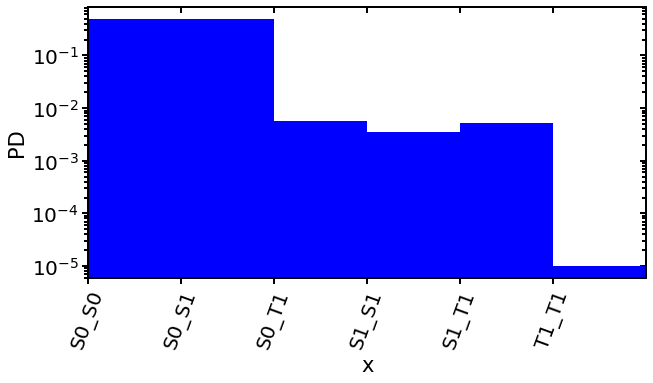

In [45]:
fig, ax = fi.FigureCollection(system).state_population(use_unique=True)

### Probability densities of time steps between emitting transitions

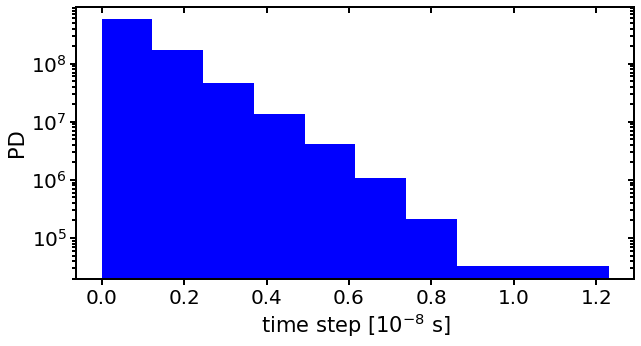

In [47]:
fig, ax = fi.FigureCollection(system).time_steps(xlabel="time step [$10^{-8}$ s]", tick_style_x="sci")

### Probability densities of time steps between all transitions

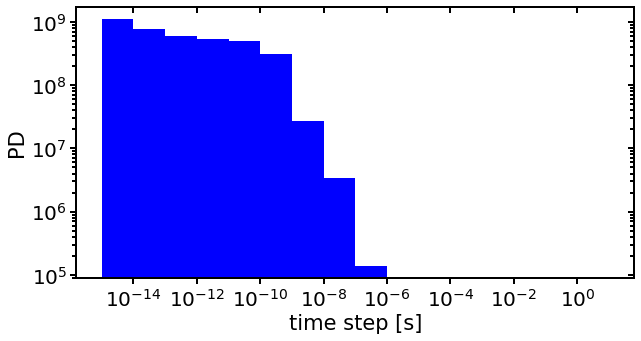

In [50]:
fig, ax = fi.FigureCollection(system).time_steps(only_emitting_transitions=False, 
                                                 xlabel="time step [s]", xscale="log",
                                                 bins=10**(np.arange(-15, 2, dtype=np.float64)))

### Mean time of each state

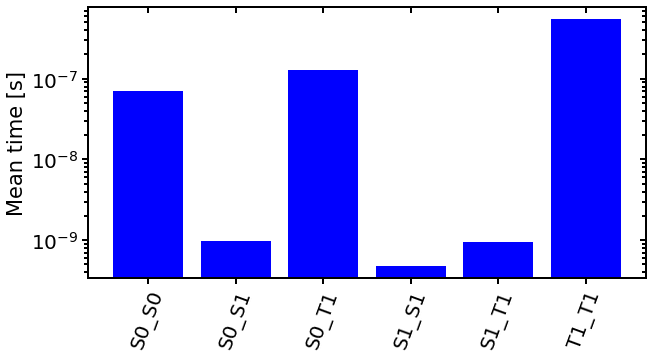

In [51]:
fig, ax = fi.FigureCollection(system).occupation_time()

### Total time spent in each state

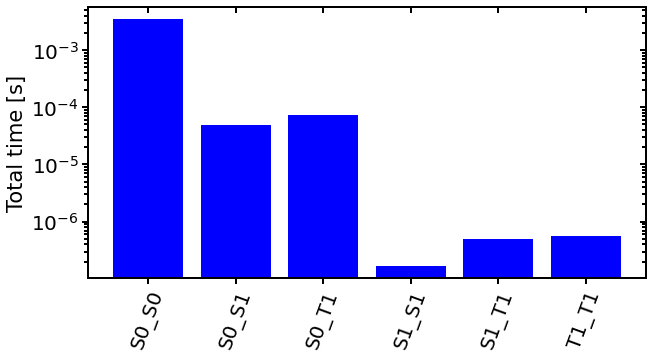

In [52]:
fig, ax = fi.FigureCollection(system).occupation_time(total=True)

## Emission analysis
Depends largely on the resample value in method 'emitters'. Do not forget to adjust the axis labels accordingly.

In [77]:
system.emitters(unit="s", resample="0.1us", photon_collection=1)
system.process()
system.fcs()

### Time series of photon counts

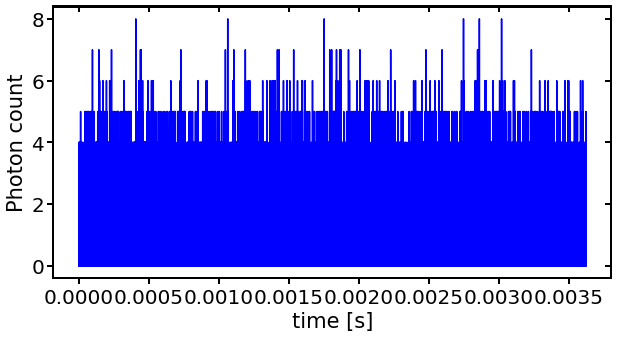

In [71]:
fig, ax = fi.FigureCollection(system).emission_events()

### Probability densities of number of photon counts

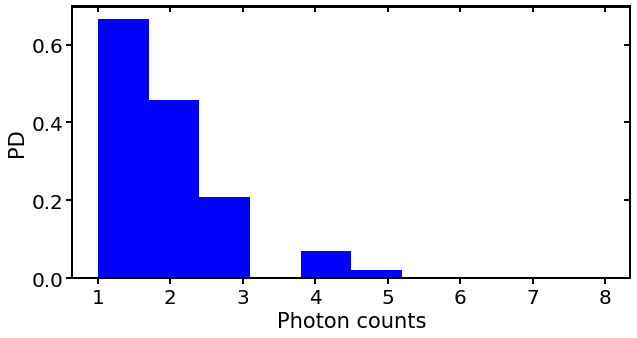

In [72]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False)

### Fluorescence correlation spectroscopy

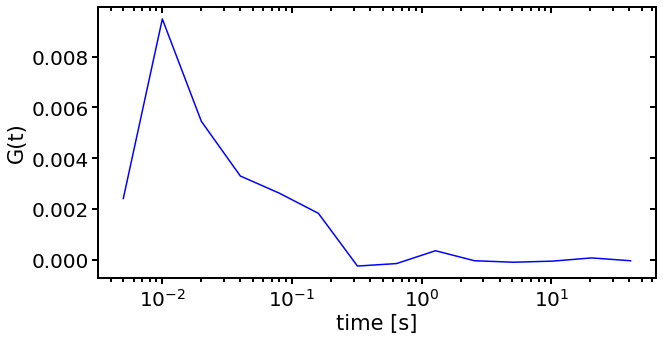

In [78]:
fig, ax = fi.FigureCollection(system).fcs()

### Probability densities of ON periods
An ON period is a number of consecutive frames where each frame contains a minimum amount of emissions. 

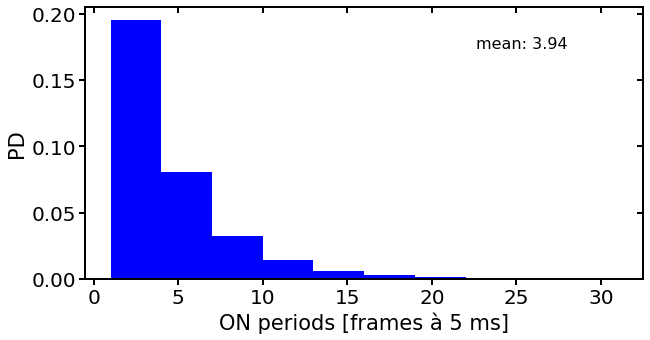

In [79]:
fig, ax = fi.FigureCollection(system).on_off()

### Probability densities of OFF periods

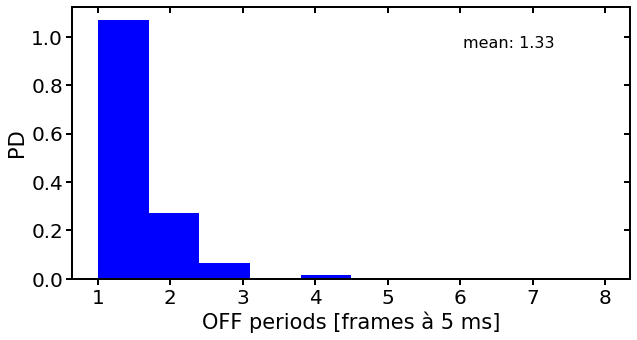

In [80]:
fig, ax = fi.FigureCollection(system).on_off(on=False)

### Time series of ON periods
Displays all ON periods consecutively with their number of frames.

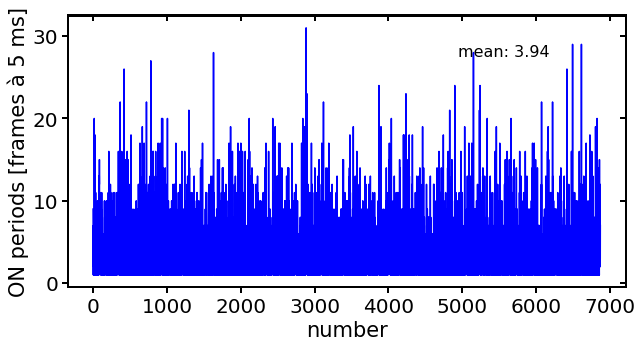

In [81]:
fig, ax = fi.FigureCollection(system).on_off(time_series=True)

### Time series of OFF periods

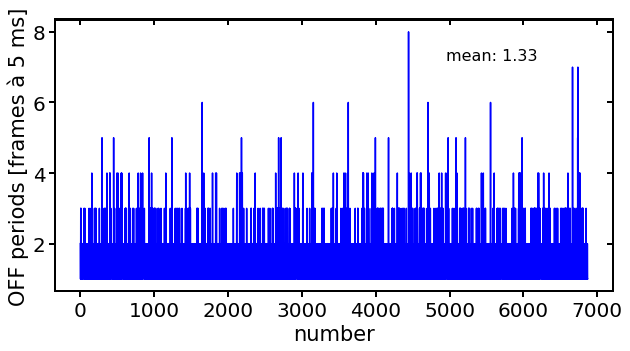

In [82]:
fig, ax = fi.FigureCollection(system).on_off(time_series=True, on=False)

## Multiple runs

In [180]:
class_args = dict(number=3, distances=1, rates=rate_dict)
simulate_args = dict(n_steps=100000, base="cy")
emitting_args = dict(unit="s", resample="5ms")

In [181]:
%%time
systems = ls.multiple_simulations(10, "Jablonski", class_args, simulate_args, emitting_args, 100)

CPU times: total: 23.2 s
Wall time: 23.2 s


In [203]:
data = [[system.pandas_series.index, system.pandas_series.values] for system in systems]

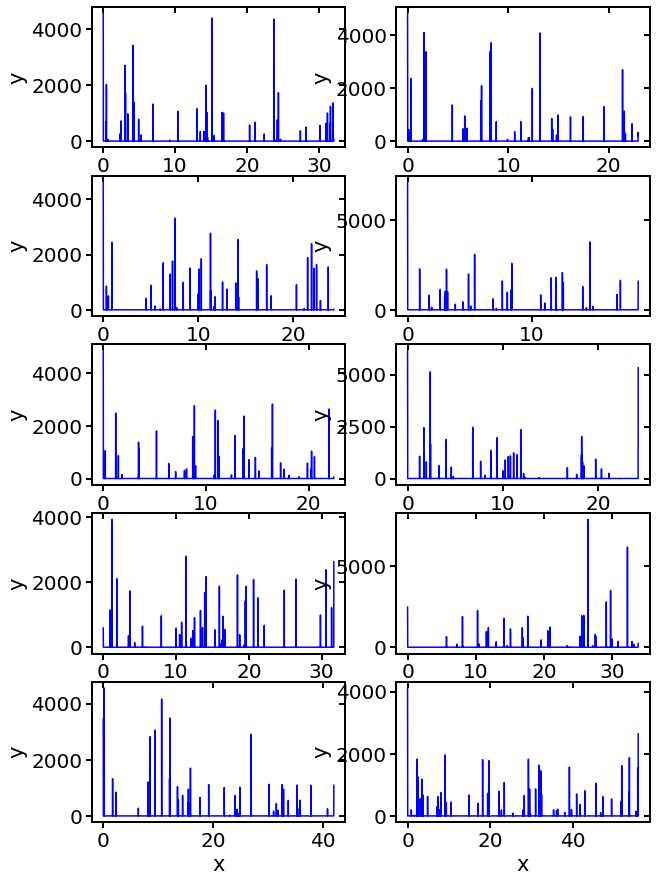

In [204]:
fig, ax = cp.universal_figure(nrows=-(len(systems)//-2), ncols=2, width=10, 
                              height=-(len(systems)//-2)*3, type_="line", data=data)